# 03 - Embryo Bulk Composition (~5 Myr)

This notebook establishes the bulk composition of planetary embryos at the end of the gas disk phase (~5 Myr) by tracing collision histories from N-body simulations.

It covers:
- Loading N-body simulation snapshots (`aei` files) and converting mass to Earth units
- Classifying initial particle compositions by semi-major axis (EF / EC / OC / CI)
- Loading collision records and filtering events within the gas disk lifetime
- Tracing full collision histories using `CollisionTracer` to reconstruct compositional mixing
- Calculating meteorite mass fractions and thermodynamic conditions (P, T)
- Assigning bulk geochemical compositions using `EarlyComUpdater`
- Filtering embryos (m ≥ 0.05 M⊕) and visualizing CI-normalized spider diagrams
- Exporting the full particle dataset (`df_gas_all`) to CSV

> **Prerequisites:** Run `01_constants_and_setup.ipynb` and `02_meteorite_bulk_composition.ipynb` first.  
> **Input:** `./Tables/Meteorites_composition.csv`  
> **Output:** `./Tables/03_embryo_bulk_composition.csv`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import matplotlib.patches as mpatches
sys.path.append('../../src')
import accrediff as ad

# ── Plot style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
})

Colors = {
    'Earth'  : "#1f77b4",
    'Mars'   : "#d62728",
    'EF'     : "#8c564b",
    'EC'     : "#ff7f0e",
    'OC'     : "#2ca02c",
    'CI'     : "#9467bd",
}

print("Setup complete.")

Setup complete.


## 1. Load N-body Simulation Data

Read all `aei` snapshot files from the selected model directory.  
Each snapshot contains orbital elements and masses for all particles at a given time step (0.1 Myr interval).

- Mass is converted from solar units to Earth mass units (`m_e = m / ME`)
- Particle index `i` is used as the DataFrame index for cross-snapshot tracking

In [2]:
# ── Model selection ──────────────────────────────────────
model      = 'note_02'
Path       = f'../dataset/N_body_dataset/{model}/'

# ── Load all aei snapshots ───────────────────────────────
file_paths = sorted(
    [os.path.join(Path, f) for f in os.listdir(Path) if f.startswith('aei')]
)
keys = [f'{i/10:.1f} Myr' for i in range(len(file_paths))]

col_names = ['t', 'i', 'a', 'e', 'inc', 'Omega', 'w', 'T', 'E', 'M', 'm', 'r']
A_dict = {}
for path, key in zip(file_paths, keys):
    A_dict[key] = pd.read_csv(
        path, sep=' ', header=None, names=col_names, index_col='i'
    )

# Convert mass to Earth units
for key in A_dict:
    A_dict[key]['m_e'] = A_dict[key]['m'] / ad.constants.ME
    A_dict[key]['N']   = len(A_dict[key])

print(f"Model   : {model}")
print(f"Snapshots loaded: {len(A_dict)}")
print(f"Time range: {list(A_dict.keys())[0]} → {list(A_dict.keys())[-1]}")

Model   : note_02
Snapshots loaded: 1001
Time range: 0.0 Myr → 100.0 Myr


## 2. Initial Composition Classification (t = 0 Myr)

Particles are assigned a meteorite composition type based on their initial semi-major axis:

| Semi-major axis (AU) | Composition type |
|---------------------|-----------------|
| a ≤ 1.0             | EF              |
| 1.0 < a ≤ 1.3       | EC              |
| 1.3 < a ≤ 3.0       | OC              |
| a > 3.0             | CI              |

The two outermost giant planets (index 0 and 1) are excluded.

In [3]:
time_zero = '0.0 Myr'
df_com = A_dict[time_zero][['a', 'e', 'inc', 'm_e']].iloc[2:]  # remove giant planets

conditions = [
    (df_com['a'] <= 1.0),
    (df_com['a'] > 1.0) & (df_com['a'] <= 1.3),
    (df_com['a'] > 1.3) & (df_com['a'] <= 3.0),
    (df_com['a'] > 3.0),
]
choices = ['EF', 'EC', 'OC', 'CI']
df_com['com'] = np.select(conditions, choices, default=None)
i_com_mapping = dict(zip(df_com.index, df_com['com']))

# Summary
for c in choices:
    n = (df_com['com'] == c).sum()
    print(f"  {c}: {n} particles")
print(f"  Total: {len(df_com)} particles")

  EF: 2511 particles
  EC: 2493 particles
  OC: 1506 particles
  CI: 490 particles
  Total: 7000 particles


## 3. Visualize Initial Particle Distribution

Scatter plot of eccentricity vs. semi-major axis at t = 0 Myr, colored by composition type.  
A KDE curve (gray) shows the radial surface density profile.

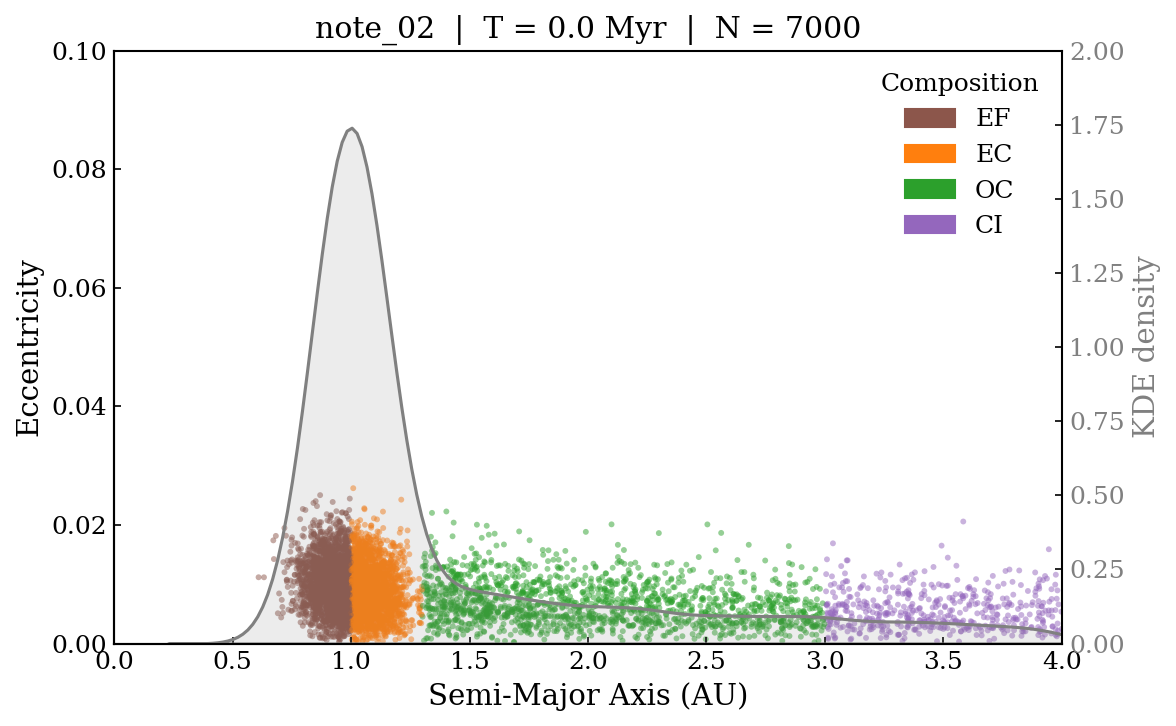

In [4]:
color_map = {c: Colors[c] for c in choices}
colors     = df_com['com'].map(color_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_com['a'], df_com['e'], c=colors, s=8, alpha=0.5, edgecolors='none')
ax.set_xlim(0, 4)
ax.set_ylim(0, 0.1)
ax.set_xlabel('Semi-Major Axis (AU)')
ax.set_ylabel('Eccentricity')
ax.set_title(f'{model}  |  T = {time_zero}  |  N = {len(df_com)}')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_handles = [mpatches.Patch(color=color_map[k], label=k) for k in choices]
ax.legend(handles=legend_handles, title='Composition', loc='upper right', frameon=False)

# KDE overlay
ax2 = ax.twinx()
sns.kdeplot(df_com['a'], ax=ax2, color='gray', linewidth=1.5, fill=True, alpha=0.15)
ax2.set_ylim(0, 2)
ax2.set_ylabel('KDE density', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

## 4. Load Collision Records & Filter Gas-Disk Phase

Collision events are read from the `Collision` file in the model directory.  
Only collisions occurring **within the gas disk lifetime** (t ≤ 5 Myr) are retained.

In [5]:
# ── Locate collision file ────────────────────────────────
collision_files = [
    os.path.join(Path, f) for f in os.listdir(Path) if f.startswith('Collision')
]
if not collision_files:
    raise FileNotFoundError(f"No Collision file found in {Path}")

col_names_c = [
    'time',
    'indexi', 'mi', 'ri', 'xi', 'yi', 'zi', 'vxi', 'vyi', 'vzi', 'Sxi', 'Syi', 'Szi',
    'indexj', 'mj', 'rj', 'xj', 'yj', 'zj', 'vxj', 'vyj', 'vzj', 'Sxj', 'Syj', 'Szj',
]

C_data = pd.read_csv(collision_files[0], sep=r'\s+', header=None, names=col_names_c)
C_data['m_ei'] = C_data['mi'] / ad.constants.ME
C_data['m_ej'] = C_data['mj'] / ad.constants.ME

# Filter: gas disk phase only
gas_time   = '5.0 Myr'
gas_time_yr = A_dict[gas_time]['t'].iloc[0]
C_withgas  = C_data[C_data['time'] <= gas_time_yr].copy()

print(f"Gas disk lifetime : {gas_time_yr:.0f} yr")
print(f"Total collisions  : {len(C_data)}")
print(f"Within gas disk   : {len(C_withgas)}")

Gas disk lifetime : 4928131 yr
Total collisions  : 5790
Within gas disk   : 5263


## 5. Classify Particles at t = 5 Myr

Particles surviving to the end of the gas disk phase are split into two groups:

- **Non-collided** (`df_gas_original`): retain their original `t = 0` composition
- **Collided** (`df_gas_collision`): composition must be reconstructed from collision history

In [6]:
df_gas = A_dict[gas_time][['a', 'e', 'inc', 'm_e']].iloc[2:].copy()

gas_index_set      = set(df_gas.index)
collision_id_set   = set(C_withgas['indexi']) | set(C_withgas['indexj'])
intersection_list  = list(gas_index_set & collision_id_set)
original_list      = list(gas_index_set - collision_id_set)

# Initialize composition columns
for col in choices:
    df_gas[col] = np.nan

df_gas_collision = df_gas.loc[intersection_list].copy()
df_gas_original  = df_gas.loc[original_list].copy()

print(f"Particles at {gas_time}    : {len(df_gas)}")
print(f"  Non-collided             : {len(df_gas_original)}")
print(f"  Collided (need tracing)  : {len(df_gas_collision)}")

Particles at 5.0 Myr    : 1244
  Non-collided             : 903
  Collided (need tracing)  : 341


## 6. Assign Compositions

### 6a. Non-collided Particles
Directly inherit the composition type from `t = 0` classification.

### 6b. Collided Particles — Collision History Tracing
`CollisionTracer.trace_full_history()` reconstructs the full merger tree for each particle,
returning all ancestor particle indices. The mass of each ancestor is then summed by
composition category to obtain the mixed bulk composition.

In [7]:
# ── 6a: Non-collided ─────────────────────────────────────
for idx in df_gas_original.index:
    com_type = i_com_mapping.get(idx)
    if com_type in choices:
        df_gas_original.at[idx, com_type] = df_com.loc[idx, 'm_e']

# ── 6b: Collided — trace full merger history ──────────────
df_c   = C_withgas[['time', 'indexi', 'm_ei', 'indexj', 'm_ej']].copy()
tracer = ad.CollisionTracer(df_c)

for idx in df_gas_collision.index:
    h           = tracer.trace_full_history(idx)
    index_union = list(set(h['indexi']) | set(h['indexj']))

    union_data = [
        {
            'Index'   : i,
            'Category': i_com_mapping.get(i),
            'm_e'     : df_com.loc[i, 'm_e'] if i in df_com.index else None,
        }
        for i in index_union
    ]
    union_df      = pd.DataFrame(union_data)
    category_sums = union_df.groupby('Category')['m_e'].sum()

    for com_type in choices:
        if com_type in category_sums.index:
            df_gas_collision.at[idx, com_type] = category_sums[com_type]

print("Composition assignment complete.")

Composition assignment complete.


## 7. Merge, Compute Mixing Ratios & Thermodynamic Conditions

All particles are merged into `df_gas_all`.  
For each particle:
- Meteorite mass fractions (`EF_ratio`, `EC_ratio`, `OC_ratio`, `CI_ratio`) are calculated
- Formation pressure `P` is estimated from mass via `ad.Early_pressure()`
- Formation temperature `T` is derived from `P` via `ad.P_to_T()`

In [8]:
df_gas_all = (
    pd.concat([df_gas_collision, df_gas_original])
    .sort_values('m_e')
    .reset_index()
)

# Fill NaN → 0 and compute mass fractions
for col in choices:
    df_gas_all[col] = df_gas_all[col].fillna(0)

total = df_gas_all[choices].sum(axis=1).replace(0, np.nan)
for col in choices:
    df_gas_all[f'{col}_ratio'] = df_gas_all[col] / total

# Thermodynamic conditions
df_gas_all['P'] = ad.Early_pressure(df_gas_all['m_e'])
df_gas_all['T'] = df_gas_all['P'].apply(ad.P_to_T)

print(f"Total particles in df_gas_all: {len(df_gas_all)}")
df_gas_all.head()

Total particles in df_gas_all: 1244


,i,a,e,inc,m_e,EF,EC,OC,CI,EF_ratio,EC_ratio,OC_ratio,CI_ratio,P,T
0,6170,1.885426,0.055145,0.026060,0.000215,0.0,0.0,0.000215,0.000000,0.0,0.0,1.0,0.0,0.394052,1895.573320
1,5974,1.328577,0.136199,0.125076,0.000367,0.0,0.0,0.000367,0.000000,0.0,0.0,1.0,0.0,0.411129,1896.496133
2,5069,2.733346,0.174028,0.035980,0.000396,0.0,0.0,0.000000,0.000396,0.0,0.0,0.0,1.0,0.414360,1896.670589
3,6279,2.010899,0.110985,0.049694,0.000401,0.0,0.0,0.000401,0.000000,0.0,0.0,1.0,0.0,0.414989,1896.704561
4,5550,2.865501,0.364656,0.360332,0.000402,0.0,0.0,0.000000,0.000402,0.0,0.0,0.0,1.0,0.415017,1896.706052


## 8. Assign Geochemical Bulk Compositions

Load the meteorite geochemical composition table from `02_meteorite_bulk_composition.ipynb` output.  
Each particle's bulk composition (MgO, Al₂O₃, CaO, FeO, NiO, SiO₂, Fe, Ni, Si, O) is
calculated as the mass-fraction-weighted mixture of its constituent meteorite types via `EarlyComUpdater`.

In [9]:
# ── Load meteorite composition table ─────────────────────
Mete_file = './Tables/Meteorites_composition.csv'
df_Mete   = pd.read_csv(Mete_file, index_col=0)

# Normalize each column (component) to sum = 1
col_sums  = df_Mete.sum(numeric_only=True)
safe_sums = col_sums.replace(0, np.nan)
df_norm   = df_Mete.div(safe_sums, axis=1)
dict_Mete = df_norm.to_dict()

# ── Define element groups ─────────────────────────────────
Elements     = ad.constants.Elements
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items   = ['Fe', 'Ni', 'Si', 'O']
major_items  = mantle_items + core_items

calc = ad.MolarMassCalculator(mass_table=Elements)
for item in mantle_items:
    Elements[item] = calc.molar_mass(item)

# ── Assign bulk compositions ──────────────────────────────
for col in major_items:
    df_gas_all[col] = np.nan

updater = ad.EarlyComUpdater(df_gas_all, dict_Mete, major_items, ad)
updater.batch_update()

print("Bulk composition assignment complete.")
df_gas_all[major_items].describe()

Bulk composition assignment complete.


,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O
count,1244.000000,1244.000000,1244.000000,1244.000000,1244.000000,1244.000000,1244.000000,1244.000000,1.244000e+03,1244.000000
mean,0.344786,0.013207,0.019413,0.164548,0.001089,0.349812,0.090642,0.012801,3.703623e-03,0.006163
std,0.014200,0.002165,0.003164,0.086017,0.001743,0.039982,0.092477,0.001660,9.621262e-03,0.005236
min,0.305443,0.010193,0.014472,0.003479,0.000001,0.182637,0.004220,0.010823,3.769522e-08,0.000439
25%,0.338081,0.012646,0.018756,0.170390,0.000209,0.328082,0.062375,0.012319,9.024467e-06,0.004145
50%,0.350476,0.012646,0.018756,0.170419,0.000212,0.372605,0.062546,0.012331,9.272070e-06,0.004241
75%,0.350476,0.013408,0.019577,0.170591,0.000228,0.372605,0.062576,0.012334,9.313353e-06,0.004278
max,0.381900,0.022718,0.033171,0.281078,0.004732,0.376687,0.318796,0.017571,6.028236e-02,0.029845


## 9. Filter Embryos (m ≥ 0.05 M⊕)

Planetary embryos are defined as particles with mass ≥ 0.05 Earth masses.  
They are sorted by mass (descending) and assigned sequential IDs (`Embryo 1`, `Embryo 2`, ...).  
Colors skip indices 0 (blue) and 3 (red) from `tab10`, which are reserved for Earth and Mars.

In [10]:
df_embryos = (
    df_gas_all[df_gas_all['m_e'] >= 0.05]
    .sort_values('m_e', ascending=False)
    .reset_index(drop=True)
)
embryos_id = [f'Embryo {i+1}' for i in range(len(df_embryos))]

# Assign colors (skip blue=0 and red=3 reserved for Earth/Mars)
cmap          = plt.get_cmap('tab10')
color_indices = [i for i in range(10) if i not in (0, 3)]
embryo_colors = [cmap(color_indices[i % len(color_indices)]) for i in range(len(df_embryos))]

print(f"Number of embryos (m ≥ 0.05 M⊕): {len(df_embryos)}")
df_embryos[['m_e', 'a', 'P', 'T'] + choices]

Number of embryos (m ≥ 0.05 M⊕): 6


,m_e,a,P,T,EF,EC,OC,CI
0,0.534792,0.737150,60.298777,3568.182619,0.262669,0.259380,0.012742,0.000000
1,0.308318,1.028903,34.920117,2849.315965,0.113802,0.137479,0.055347,0.001691
2,0.292248,0.852052,33.119358,2785.885075,0.104263,0.149899,0.037410,0.000677
3,0.256534,0.579128,29.117178,2638.218566,0.109186,0.140348,0.007000,0.000000
4,0.156218,0.650397,17.875802,2419.092362,0.069915,0.082593,0.003710,0.000000
5,0.125669,1.127397,14.452505,2369.922203,0.050475,0.056864,0.018330,0.000000


## 10. CI-Normalized Spider Diagram

Embryo compositions are normalized to both **Mg** and **CI chondrites**:

$$\left(\frac{X}{\text{Mg}}\right)_{\text{CI}} = \frac{(X/\text{MgO})_{\text{embryo}}}{(X/\text{MgO})_{\text{CI}}}$$

- **Mantle** elements (Al, Ca, Fe, Ni, Si): square markers (`s`)
- **Core** elements (Fe, Ni, Si): circle markers (`o`)
- Marker size scales with embryo mass

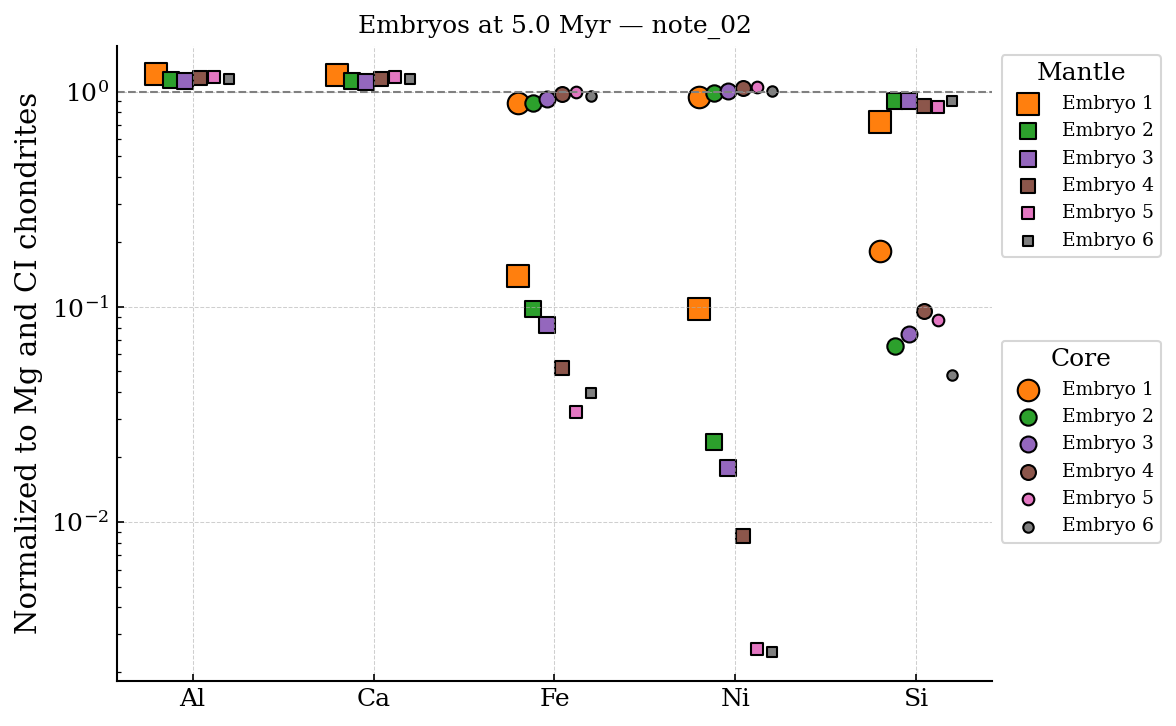

In [11]:
# ── Normalize to MgO ─────────────────────────────────────
df_embryos_Mg = df_embryos[major_items].div(df_embryos['MgO'].values, axis=0)

# ── Normalize to CI ───────────────────────────────────────
CI_bulk_mg    = ad.constants.CI_bulk_mg
df_CI         = pd.DataFrame([CI_bulk_mg])

mantle_keys = mantle_items[1:]          # Al2O3, CaO, FeO, NiO, SiO2
core_keys   = core_items[:-1]           # Fe, Ni, Si
ci_core_ref = mantle_items[3:]          # FeO, NiO, SiO2 as CI reference for core

df_embryos_CI = df_embryos_Mg[mantle_keys + core_keys].copy()
df_embryos_CI[mantle_keys] = df_embryos_CI[mantle_keys].div(df_CI[mantle_keys].values[0])
df_embryos_CI[core_keys]   = df_embryos_CI[core_keys].div(df_CI[ci_core_ref].values[0])

# ── Plot ──────────────────────────────────────────────────
elements = ['Al', 'Ca', 'Fe', 'Ni', 'Si']
x_idx    = np.arange(len(elements))
xx_idx   = np.array([2, 3, 4])
offsets  = np.linspace(-0.2, 0.2, len(df_embryos_CI))

fig, ax = plt.subplots(figsize=(8, 5))
legend_groups = {'Mantle': [], 'Core': []}

for i in range(len(df_embryos_CI)):
    s = 200 * df_embryos['m_e'].iloc[i]
    c = embryo_colors[i]

    sc_m = ax.scatter(x_idx  + offsets[i], df_embryos_CI[mantle_keys].iloc[i].values,
                      marker='s', s=s, color=c, edgecolor='k',
                      label=f'{embryos_id[i]} mantle')
    sc_c = ax.scatter(xx_idx + offsets[i], df_embryos_CI[core_keys].iloc[i].values,
                      marker='o', s=s, color=c, edgecolor='k',
                      label=f'{embryos_id[i]} core')
    legend_groups['Mantle'].append(sc_m)
    legend_groups['Core'].append(sc_c)

ax.set_yscale('log')
ax.set_xticks(x_idx)
ax.set_xticklabels(elements)
ax.set_ylabel('Normalized to Mg and CI chondrites')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.grid(True, which='major', ls='--', lw=0.5, alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(f'Embryos at {gas_time} — {model}', fontsize=12)

leg1 = ax.legend(legend_groups['Mantle'], embryos_id, title='Mantle',
                 bbox_to_anchor=(1.0, 1.0), loc='upper left', fontsize=9)
ax.add_artist(leg1)
ax.legend(legend_groups['Core'], embryos_id, title='Core',
          bbox_to_anchor=(1.0, 0.55), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Export Results

Save the full particle dataset `df_gas_all` (all particles at t = 5 Myr) to CSV.  
The exported file contains:

| Column group | Columns |
|--------------|---------|
| Orbital elements | `a`, `e`, `inc`, `m_e` |
| Meteorite mass (M⊕) | `EF`, `EC`, `OC`, `CI` |
| Mixing ratios | `EF_ratio`, `EC_ratio`, `OC_ratio`, `CI_ratio` |
| Thermodynamic conditions | `P`, `T` |
| Geochemical bulk composition | `MgO`, `Al2O3`, `CaO`, `FeO`, `NiO`, `SiO2`, `Fe`, `Ni`, `Si`, `O` |

In [12]:
df_gas_all

,i,a,e,inc,m_e,EF,EC,OC,CI,EF_ratio,...,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O
0,6170,1.885426,0.055145,0.026060,0.000215,0.000000,0.000000,0.000215,0.000000,0.000000,...,0.350476,0.012646,0.018756,0.170354,0.000206,0.372605,0.062612,0.012337,9.363221e-06,0.004309
1,5974,1.328577,0.136199,0.125076,0.000367,0.000000,0.000000,0.000367,0.000000,0.000000,...,0.350476,0.012646,0.018756,0.170369,0.000207,0.372605,0.062596,0.012336,9.341574e-06,0.004292
2,5069,2.733346,0.174028,0.035980,0.000396,0.000000,0.000000,0.000000,0.000396,0.000000,...,0.338081,0.013408,0.019577,0.280679,0.004247,0.328082,0.004619,0.011308,4.364732e-08,0.015927
3,6279,2.010899,0.110985,0.049694,0.000401,0.000000,0.000000,0.000401,0.000000,0.000000,...,0.350476,0.012646,0.018756,0.170373,0.000208,0.372605,0.062593,0.012335,9.336684e-06,0.004288
4,5550,2.865501,0.364656,0.360332,0.000402,0.000000,0.000000,0.000000,0.000402,0.000000,...,0.338081,0.013408,0.019577,0.280680,0.004249,0.328082,0.004618,0.011306,4.362293e-08,0.015923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1239,2327,0.650397,0.085968,0.031682,0.156218,0.069915,0.082593,0.003710,0.000000,0.447549,...,0.340731,0.015857,0.022943,0.009320,0.000040,0.280633,0.285547,0.016380,2.855039e-02,0.000948
1240,1442,0.579128,0.056310,0.013556,0.256534,0.109186,0.140348,0.007000,0.000000,0.425621,...,0.339213,0.015591,0.022548,0.014925,0.000135,0.281273,0.278746,0.016232,3.133698e-02,0.002496
1241,93,0.852052,0.009143,0.033901,0.292248,0.104263,0.149899,0.037410,0.000677,0.356761,...,0.338560,0.014983,0.021704,0.023581,0.000278,0.298197,0.262644,0.015644,2.440975e-02,0.004456
1242,4189,1.028903,0.069765,0.013560,0.308318,0.113802,0.137479,0.055347,0.001691,0.369106,...,0.341927,0.015274,0.022171,0.028185,0.000371,0.298390,0.256528,0.015417,2.173786e-02,0.005621


In [13]:
import pathlib

save_dir  = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)

save_file = save_dir / '03_embryo_bulk_composition.csv'
df_gas_all.to_csv(save_file, index=True)
print(f"Saved: {save_file}")

# Verify
pd.read_csv(save_file, index_col=0).head()

Saved: Tables/03_embryo_bulk_composition.csv



,i,a,e,inc,m_e,EF,EC,OC,CI,EF_ratio,...,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O
0,6170,1.885426,0.055145,0.026060,0.000215,0.0,0.0,0.000215,0.000000,0.0,...,0.350476,0.012646,0.018756,0.170354,0.000206,0.372605,0.062612,0.012337,9.363221e-06,0.004309
1,5974,1.328577,0.136199,0.125076,0.000367,0.0,0.0,0.000367,0.000000,0.0,...,0.350476,0.012646,0.018756,0.170369,0.000207,0.372605,0.062596,0.012336,9.341574e-06,0.004292
2,5069,2.733346,0.174028,0.035980,0.000396,0.0,0.0,0.000000,0.000396,0.0,...,0.338081,0.013408,0.019577,0.280679,0.004247,0.328082,0.004619,0.011308,4.364732e-08,0.015927
3,6279,2.010899,0.110985,0.049694,0.000401,0.0,0.0,0.000401,0.000000,0.0,...,0.350476,0.012646,0.018756,0.170373,0.000208,0.372605,0.062593,0.012335,9.336684e-06,0.004288
4,5550,2.865501,0.364656,0.360332,0.000402,0.0,0.0,0.000000,0.000402,0.0,...,0.338081,0.013408,0.019577,0.280680,0.004249,0.328082,0.004618,0.011306,4.362293e-08,0.015923


## 13. Summary

| Step | Operation | Output |
|------|-----------|--------|
| 1 | Load N-body snapshots | `A_dict` (1001 time steps) |
| 2 | Classify initial compositions by semi-major axis | `df_com`, `i_com_mapping` |
| 3 | Visualize initial particle distribution | scatter + KDE plot |
| 4 | Load & filter collision records | `C_withgas` |
| 5 | Split particles: collided vs. non-collided | `df_gas_collision`, `df_gas_original` |
| 6 | Trace collision histories & assign compositions | Updated `df_gas_collision` |
| 7 | Merge & compute mixing ratios, P, T | `df_gas_all` |
| 8 | Assign geochemical bulk compositions | `df_gas_all` with `major_items` |
| 9 | Filter embryos (m ≥ 0.1 M⊕) | `df_embryos` |
| 10 | Raw bulk composition spider diagram | X/MgO line plot |
| 11 | CI-normalized spider diagram | Mantle + Core scatter plot |
| 12 | Export to CSV | `./Tables/03_embryo_bulk_composition.csv` |

➡️ **Next:** `04_differentiation.ipynb`